# Tarea 4 — Vibraciones de una barra con resorte
IMEC 4001 — Matemáticas Aplicadas  
Universidad de los Andes · 2026-2

**Estudiante:** Luis Alejandro Rodríguez


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq


## Ejercicio 2c

A partir de las condiciones de borde de los dos casos se obtiene la misma ecuación característica:

$$
(\beta L)\tan(\beta L)=\frac{kL}{EA}.
$$

Definiendo

$$
\lambda=\beta L,
\qquad
\gamma=\frac{kL}{EA},
$$

la ecuación que se debe resolver numéricamente es

$$
\boxed{F(\lambda)=\lambda\tan(\lambda)-\gamma=0}.
$$

Los valores de $\lambda_i$ corresponden a las raíces positivas de esta ecuación. Luego,

$$
\beta_i=\frac{\lambda_i}{L},
\qquad
\alpha_i=\beta_i^2.
$$


### Parámetros

Se consideran

$$
L=1,\qquad \rho=1,
$$

y los valores indicados para el parámetro $kL/(EA)$:

$$
\frac{kL}{EA}\in\{0.1,\,1,\,10\}.
$$


In [2]:
# Parámetros
L = 1
rho = 1

parametros = [0.1, 1, 10]
n_modos = 3

display(f"L = {L}")
display(f"rho = {rho}")
display(f"Parametros kL/(EA) = {parametros}")


'L = 1'

'rho = 1'

'Parametros kL/(EA) = [0.1, 1, 10]'

### Función característica

Para cada valor de $kL/(EA)$ se define

$$
F(\lambda)=\lambda\tan(\lambda)-\frac{kL}{EA}.
$$

Los primeros tres ceros positivos se buscan en los intervalos

$$
(0,\pi/2),\qquad
(\pi,3\pi/2),\qquad
(2\pi,5\pi/2).
$$

Se utiliza `brentq`, que encuentra una raíz de una función no lineal dentro de un intervalo donde la función cambia de signo.


In [3]:
def funcion(lambda_, gamma):
    return lambda_ * np.tan(lambda_) - gamma


def calcular_raices(gamma, n_modos=3):
    raices = []

    for n in range(n_modos):
        a = n * np.pi + 1e-10
        b = n * np.pi + np.pi / 2 - 1e-10

        raiz = brentq(funcion, a, b, args=(gamma,))
        raices.append(raiz)

    return np.array(raices)


In [4]:
# Cálculo de los tres primeros parámetros lambda_i

resultados = {}

for gamma in parametros:
    lambdas = calcular_raices(gamma, n_modos)
    resultados[gamma] = lambdas

    display(f"kL/(EA) = {gamma}")
    for i, value in enumerate(lambdas, start=1):
        display(f"lambda_{i} = {value:.6f}")


'kL/(EA) = 0.1'

'lambda_1 = 0.311053'

'lambda_2 = 3.173097'

'lambda_3 = 6.299059'

'kL/(EA) = 1'

...

'lambda_3 = 6.437298'

'kL/(EA) = 10'

'lambda_1 = 1.428870'

'lambda_2 = 4.305801'

'lambda_3 = 7.228110'

### Resultados

Los valores obtenidos numéricamente son los tres primeros ceros positivos de $F(\lambda)$ para cada valor del parámetro.


In [5]:
print(f"{'kL/(EA)':>10} {'lambda_1':>12} {'lambda_2':>12} {'lambda_3':>12}")
print("-" * 50)

for gamma in parametros:
    lambdas = resultados[gamma]
    print(
        f"{gamma:10.1f}"
        f"{lambdas[0]:12.6f}"
        f"{lambdas[1]:12.6f}"
        f"{lambdas[2]:12.6f}"
    )


   kL/(EA)     lambda_1     lambda_2     lambda_3
--------------------------------------------------
       0.1    0.311053    3.173097    6.299059
       1.0    0.860334    3.425618    6.437298
      10.0    1.428870    4.305801    7.228110


### Verificación gráfica

Se grafica $F(\lambda)$ para cada parámetro y se marcan las tres raíces encontradas por el algoritmo.


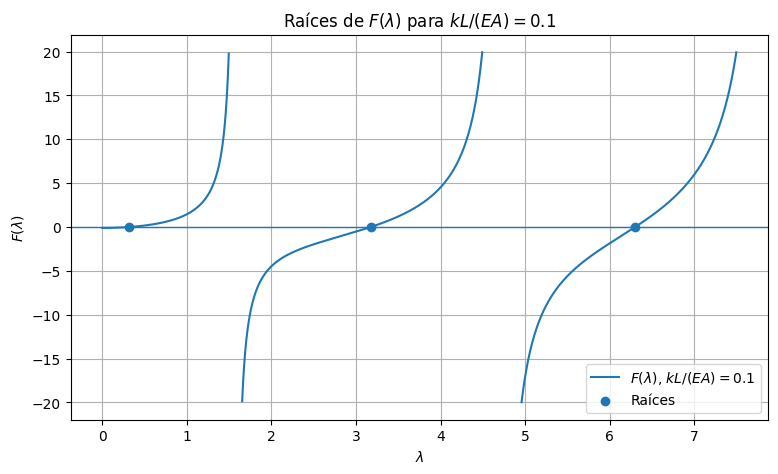

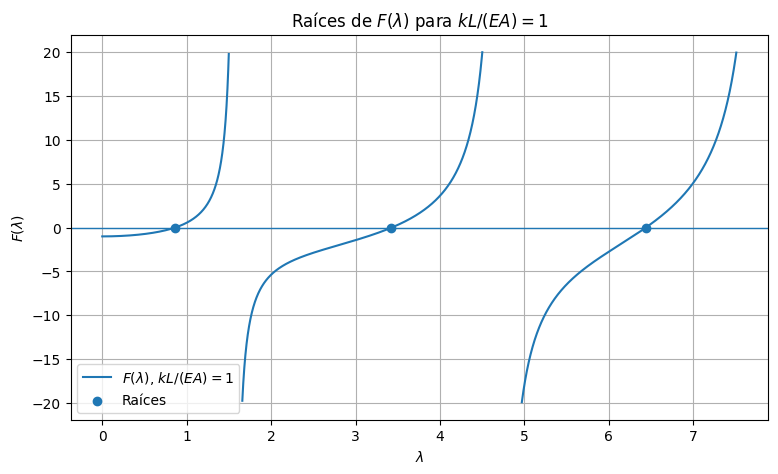

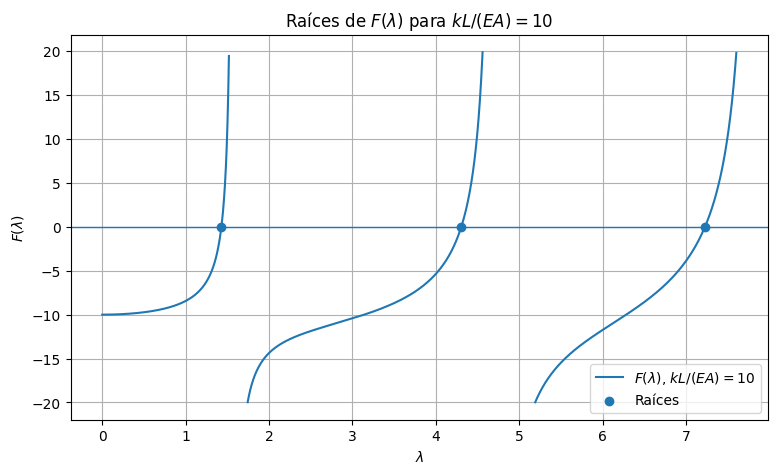

In [6]:
for gamma in parametros:
    lambdas = resultados[gamma]

    x_max = 2.5 * np.pi
    x = np.linspace(0, x_max, 5000)
    y = funcion(x, gamma)

    # Evitar valores muy grandes cerca de las asíntotas
    y[np.abs(y) > 20] = np.nan

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, label=fr"$F(\lambda)$, $kL/(EA)={gamma}$")
    plt.axhline(0, linewidth=1)
    plt.scatter(
        lambdas,
        np.zeros_like(lambdas),
        zorder=3,
        label="Raíces"
    )

    plt.xlabel(r"$\lambda$")
    plt.ylabel(r"$F(\lambda)$")
    plt.title(fr"Raíces de $F(\lambda)$ para $kL/(EA)={gamma}$")
    plt.grid()
    plt.legend()
    plt.show()


### Cálculo de los autovalores $\alpha_i$

Como

$$
\lambda_i=\beta_iL,
$$

se tiene

$$
\beta_i=\frac{\lambda_i}{L}
$$

y por tanto

$$
\boxed{\alpha_i=\beta_i^2=\left(\frac{\lambda_i}{L}\right)^2}.
$$

Para $L=1$, resulta simplemente $\alpha_i=\lambda_i^2$.


In [7]:
# Autovalores alpha_i

for gamma in parametros:
    lambdas = resultados[gamma]
    alphas = (lambdas / L) ** 2

    display(f"kL/(EA) = {gamma}")
    for i, value in enumerate(alphas, start=1):
        display(f"alpha_{i} = {value:.6f}")


'kL/(EA) = 0.1'

'alpha_1 = 0.096754'

'alpha_2 = 10.068546'

'alpha_3 = 39.678149'

'kL/(EA) = 1'

...

'alpha_3 = 41.438808'

'kL/(EA) = 10'

'alpha_1 = 2.041670'

'alpha_2 = 18.539926'

'alpha_3 = 52.245571'

### Conclusión

El algoritmo numérico permite encontrar los parámetros $\lambda_i$ que satisfacen la ecuación característica. Los dos escenarios físicos tienen la misma ecuación característica, por lo que producen los mismos autovalores. La diferencia entre los casos aparece en la forma de los modos espaciales $u_i(x)$, debido a la ubicación del resorte y del extremo libre.


## Ejercicio 2e — Frecuencias naturales

Usando la pista del profesor,

$$
\tau=ct,
\qquad
c=\sqrt{\frac{E}{\rho}},
$$

la solución temporal es

$$
T_i(t)=\cos(\lambda_i ct).
$$

Comparando con

$$
T_i(t)=\cos(\omega_i t),
$$

se obtiene

$$
\boxed{\omega_i=\lambda_i\sqrt{\frac{E}{\rho}}}.
$$

Por tanto, se usan los $\lambda_i$ calculados en el ejercicio 2c.


In [8]:
# Parámetros para calcular las frecuencias
E = 1
c = np.sqrt(E / rho)

frecuencias = {}

for gamma in parametros:
    lambdas = resultados[gamma]
    omega = c * lambdas
    frecuencias[gamma] = omega

    display(f"kL/(EA) = {gamma}")
    for i, value in enumerate(omega, start=1):
        display(f"omega_{i} = {value:.6f} rad/s")


'kL/(EA) = 0.1'

'omega_1 = 0.311053 rad/s'

'omega_2 = 3.173097 rad/s'

'omega_3 = 6.299059 rad/s'

'kL/(EA) = 1'

...

'omega_3 = 6.437298 rad/s'

'kL/(EA) = 10'

'omega_1 = 1.428870 rad/s'

'omega_2 = 4.305801 rad/s'

'omega_3 = 7.228110 rad/s'

### Resultados

Como en este cálculo se toma $E=1$ y $\rho=1$,

$$
c=\sqrt{\frac{E}{\rho}}=1,
$$

por lo que numéricamente $\omega_i=\lambda_i$.

Los valores de $\omega_i$ son iguales para ambos escenarios, porque ambos tienen los mismos $\lambda_i$.


In [9]:
print(f"{'kL/(EA)':>10} {'omega_1':>14} {'omega_2':>14} {'omega_3':>14}")
print("-" * 56)

for gamma in parametros:
    omega = frecuencias[gamma]
    print(
        f"{gamma:10.1f}"
        f"{omega[0]:14.6f}"
        f"{omega[1]:14.6f}"
        f"{omega[2]:14.6f}"
    )


   kL/(EA)        omega_1        omega_2        omega_3
--------------------------------------------------------
       0.1      0.311053      3.173097      6.299059
       1.0      0.860334      3.425618      6.437298
      10.0      1.428870      4.305801      7.228110


## Ejercicio 2g)

Se parte de la condición inicial

\[
u_0(x)=u(x,0)=1.
\]

La solución modal se escribe como

\[
u(x,t)=\sum_i \alpha_i\,T_i(t)\,U_{\lambda_i}(x).
\]

En $t=0$, usando $T_i(0)=1$:

\[
1=\sum_i\alpha_i U_{\lambda_i}(x).
\]

Por ortogonalidad de los modos, las amplitudes se calculan mediante

\[
\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L u_0(x)\,U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}
\]

y como $u_0(x)=1$:

\[
\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}
\]

Se calculan para los tres valores de $kL/E$ considerados en el numeral c).



## Interpretación de los términos

- $\alpha_i$: amplitud/peso del modo $i$. Indica cuánto contribuye ese modo a construir el desplazamiento inicial.
- $T_i(t)$: evolución temporal del modo. Para vibración libre puede escribirse como $\cos(\omega_i t)$ si la velocidad inicial es cero.
- $U_{\lambda_i}(x)$: forma espacial del modo $i$.
- $\lambda_i$: autovalor espacial, con unidades de $1/\mathrm m$.
- $u_0(x)$: forma de la barra en el instante inicial $t=0$.

Por tanto, $\alpha_i$ no es una nueva frecuencia: es el coeficiente que necesitamos multiplicar por cada modo para reconstruir $u_0(x)=1$.


In [10]:

import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.integrate import quad


In [11]:

# Parámetros adimensionales usados en el numeral c)
# gamma = kL/(EA)
# Se usan los tres casos considerados: 0.1, 1 y 10.

gammas = [0.1, 1.0, 10.0]

# Número de modos calculados
N = 10

# Tomamos L = 1 m para obtener lambda_i directamente en 1/m.
L = 1.0



### 1. Autovalores

En el numeral c) se resolvió computacionalmente la ecuación característica

\[
(\lambda_i L)\tan(\lambda_i L)=\gamma,
\qquad
\gamma=\frac{kL}{EA}.
\]

Para evitar confundir el autovalor $\lambda_i$ con el valor adimensional que se resuelve numéricamente, definimos

\[
\mu_i=\lambda_iL.
\]

Entonces

\[
\mu_i\tan(\mu_i)=\gamma,
\qquad
\lambda_i=\frac{\mu_i}{L}.
\]

Los intervalos de las raíces son

\[
(0,\pi/2),\;(\pi,3\pi/2),\;(2\pi,5\pi/2),\ldots
\]


In [12]:

def characteristic(mu, gamma):
    return mu*np.tan(mu) - gamma

def roots_for_gamma(gamma, N=N):
    roots = []
    for n in range(N):
        left = n*np.pi + 1e-10
        right = n*np.pi + np.pi/2 - 1e-10
        roots.append(brentq(characteristic, left, right, args=(gamma,)))
    return np.array(roots)

all_roots = {gamma: roots_for_gamma(gamma) for gamma in gammas}

rows = []
for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L
        rows.append([gamma, i, mu, lam])

eigenvalues = pd.DataFrame(
    rows, columns=["kL/(EA)", "modo i", "mu_i = lambda_i L", "lambda_i [1/m]"]
)

eigenvalues


,kL/(EA),modo i,mu_i = lambda_i L,lambda_i [1/m]
0,0.1,1,0.311053,0.311053
1,0.1,2,3.173097,3.173097
2,0.1,3,6.299059,6.299059
3,0.1,4,9.435376,9.435376
4,0.1,5,12.574323,12.574323
5,0.1,6,15.714327,15.714327
6,0.1,7,18.854860,18.854860
7,0.1,8,21.995695,21.995695
8,0.1,9,25.136719,25.136719
9,0.1,10,28.277870,28.277870



### 2. Modos espaciales

Para los dos escenarios espejo podemos usar:

**Escenario 1: resorte en $x=0$, extremo libre en $x=L$**

\[
U_{\lambda_i}^{(1)}(x)
=
\cos[\lambda_i(L-x)].
\]

**Escenario 2: extremo libre en $x=0$, resorte en $x=L$**

\[
U_{\lambda_i}^{(2)}(x)
=
\cos(\lambda_i x).
\]

Son imágenes especulares. Como $u_0(x)=1$ es constante, las amplitudes obtenidas para ambos escenarios son iguales.


In [13]:

def mode_case_1(x, lam, L=1.0):
    # Resorte en x=0, extremo libre en x=L
    return np.cos(lam*(L-x))

def mode_case_2(x, lam, L=1.0):
    # Extremo libre en x=0, resorte en x=L
    return np.cos(lam*x)

def amplitude(mode_function, lam, L=1.0):
    numerator = quad(lambda x: mode_function(x, lam, L), 0, L)[0]
    denominator = quad(lambda x: mode_function(x, lam, L)**2, 0, L)[0]
    return numerator / denominator


In [14]:

results = []

for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L

        alpha_1 = amplitude(mode_case_1, lam, L)
        alpha_2 = amplitude(mode_case_2, lam, L)

        results.append([
            gamma, i, mu, lam, alpha_1, alpha_2
        ])

amplitudes = pd.DataFrame(
    results,
    columns=[
        "kL/(EA)", "modo i", "mu_i", "lambda_i [1/m]",
        "alpha_i escenario 1", "alpha_i escenario 2"
    ]
)

amplitudes


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
3,0.1,4,9.435376,9.435376,-0.002244,-0.002244
4,0.1,5,12.574323,12.574323,0.001264,0.001264
5,0.1,6,15.714327,15.714327,-0.000810,-0.000810
6,0.1,7,18.854860,18.854860,0.000562,0.000562
7,0.1,8,21.995695,21.995695,-0.000413,-0.000413
8,0.1,9,25.136719,25.136719,0.000316,0.000316
9,0.1,10,28.277870,28.277870,-0.000250,-0.000250



## 3. Resultado y significado físico

Los coeficientes $\alpha_i$ son los pesos con los que se combinan los modos naturales para reproducir la condición inicial uniforme

\[
u_0(x)=1.
\]

Es decir,

\[
1\approx\sum_{i=1}^{N}\alpha_iU_{\lambda_i}(x),
\]

donde aumentar $N$ mejora la aproximación.

Los dos escenarios son simétricos respecto a la barra. Por eso, para la misma condición inicial constante, los valores de $\alpha_i$ coinciden aunque las formas espaciales estén reflejadas.

La dinámica queda determinada por

\[
\boxed{
u(x,t)=
\sum_i
\alpha_i\cos(\omega_i t)\,U_{\lambda_i}(x)
}
\]

si se considera velocidad inicial nula.


In [15]:

# Tabla compacta: primeros 3 modos, que son los calculados en el numeral c)
compact = amplitudes[amplitudes["modo i"] <= 3].copy()
compact


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
10,1.0,1,0.860334,0.860334,1.119132,1.119132
11,1.0,2,3.425618,3.425618,-0.151692,-0.151692
12,1.0,3,6.437298,6.437298,0.046594,0.046594
20,10.0,1,1.428870,1.428870,1.261963,1.261963
21,10.0,2,4.305801,4.305801,-0.393433,-0.393433
22,10.0,3,7.228110,7.228110,0.210429,0.210429



### Nota sobre $L$

En este notebook se toma $L=1\,\mathrm m$ para mostrar directamente los valores numéricos de $\lambda_i$ en $1/\mathrm m$.

Si se cambia $L$, primero se mantienen los valores adimensionales $\mu_i=\lambda_iL$ obtenidos de

\[
\mu_i\tan(\mu_i)=\frac{kL}{EA},
\]

y luego

\[
\boxed{\lambda_i=\frac{\mu_i}{L}}.
\]

Las amplitudes $\alpha_i$ no cambian por una simple elección de unidades si se mantiene la misma forma adimensional de la condición inicial y se expresa el modo con la misma normalización usada aquí.


# Punto g) — Amplitudes

A continuación se calcula la amplitud de los modos usando los resultados obtenidos anteriormente en el numeral c).


# IMEC4001 — Tarea 4 — Amplitudes $\alpha_i$

## Punto g)

Se parte de la condición inicial

$$
u_0(x)=u(x,0)=1.
$$

La solución modal se escribe como

$$
u(x,t)=\sum_i \alpha_i\,T_i(t)\,U_{\lambda_i}(x).
$$

En $t=0$, usando $T_i(0)=1$:

$$
1=\sum_i\alpha_i U_{\lambda_i}(x).
$$

Por ortogonalidad de los modos, las amplitudes se calculan mediante

$$
\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L u_0(x)\,U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}
$$

y como $u_0(x)=1$:

$$
\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}
$$

Se calculan para los tres valores de $kL/E$ considerados en el numeral c).



## Interpretación de los términos

- $\alpha_i$: amplitud/peso del modo $i$. Indica cuánto contribuye ese modo a construir el desplazamiento inicial.
- $T_i(t)$: evolución temporal del modo. Para vibración libre puede escribirse como $\cos(\omega_i t)$ si la velocidad inicial es cero.
- $U_{\lambda_i}(x)$: forma espacial del modo $i$.
- $\lambda_i$: autovalor espacial, con unidades de $1/\mathrm m$.
- $u_0(x)$: forma de la barra en el instante inicial $t=0$.

Por tanto, $\alpha_i$ no es una nueva frecuencia: es el coeficiente que necesitamos multiplicar por cada modo para reconstruir $u_0(x)=1$.


In [16]:

import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.integrate import quad


In [17]:

# Parámetros adimensionales usados en el numeral c)
# gamma = kL/(EA)
# Se usan los tres casos considerados: 0.1, 1 y 10.

gammas = [0.1, 1.0, 10.0]

# Número de modos calculados
N = 10

# Tomamos L = 1 m para obtener lambda_i directamente en 1/m.
L = 1.0



### 1. Autovalores

En el numeral c) se resolvió computacionalmente la ecuación característica

$$
(\lambda_i L)\tan(\lambda_i L)=\gamma,
\qquad
\gamma=\frac{kL}{EA}.
$$

Para evitar confundir el autovalor $\lambda_i$ con el valor adimensional que se resuelve numéricamente, definimos

$$
\mu_i=\lambda_iL.
$$

Entonces

$$
\mu_i\tan(\mu_i)=\gamma,
\qquad
\lambda_i=\frac{\mu_i}{L}.
$$

Los intervalos de las raíces son

$$
(0,\pi/2),\;(\pi,3\pi/2),\;(2\pi,5\pi/2),\ldots
$$


In [18]:

def characteristic(mu, gamma):
    return mu*np.tan(mu) - gamma

def roots_for_gamma(gamma, N=N):
    roots = []
    for n in range(N):
        left = n*np.pi + 1e-10
        right = n*np.pi + np.pi/2 - 1e-10
        roots.append(brentq(characteristic, left, right, args=(gamma,)))
    return np.array(roots)

all_roots = {gamma: roots_for_gamma(gamma) for gamma in gammas}

rows = []
for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L
        rows.append([gamma, i, mu, lam])

eigenvalues = pd.DataFrame(
    rows, columns=["kL/(EA)", "modo i", "mu_i = lambda_i L", "lambda_i [1/m]"]
)

eigenvalues


,kL/(EA),modo i,mu_i = lambda_i L,lambda_i [1/m]
0,0.1,1,0.311053,0.311053
1,0.1,2,3.173097,3.173097
2,0.1,3,6.299059,6.299059
3,0.1,4,9.435376,9.435376
4,0.1,5,12.574323,12.574323
5,0.1,6,15.714327,15.714327
6,0.1,7,18.854860,18.854860
7,0.1,8,21.995695,21.995695
8,0.1,9,25.136719,25.136719
9,0.1,10,28.277870,28.277870



### 2. Modos espaciales

Para los dos escenarios espejo podemos usar:

**Escenario 1: resorte en $x=0$, extremo libre en $x=L$**

$$
U_{\lambda_i}^{(1)}(x)
=
\cos[\lambda_i(L-x)].
$$

**Escenario 2: extremo libre en $x=0$, resorte en $x=L$**

$$
U_{\lambda_i}^{(2)}(x)
=
\cos(\lambda_i x).
$$

Son imágenes especulares. Como $u_0(x)=1$ es constante, las amplitudes obtenidas para ambos escenarios son iguales.


In [19]:

def mode_case_1(x, lam, L=1.0):
    # Resorte en x=0, extremo libre en x=L
    return np.cos(lam*(L-x))

def mode_case_2(x, lam, L=1.0):
    # Extremo libre en x=0, resorte en x=L
    return np.cos(lam*x)

def amplitude(mode_function, lam, L=1.0):
    numerator = quad(lambda x: mode_function(x, lam, L), 0, L)[0]
    denominator = quad(lambda x: mode_function(x, lam, L)**2, 0, L)[0]
    return numerator / denominator


In [20]:

results = []

for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L

        alpha_1 = amplitude(mode_case_1, lam, L)
        alpha_2 = amplitude(mode_case_2, lam, L)

        results.append([
            gamma, i, mu, lam, alpha_1, alpha_2
        ])

amplitudes = pd.DataFrame(
    results,
    columns=[
        "kL/(EA)", "modo i", "mu_i", "lambda_i [1/m]",
        "alpha_i escenario 1", "alpha_i escenario 2"
    ]
)

amplitudes


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
3,0.1,4,9.435376,9.435376,-0.002244,-0.002244
4,0.1,5,12.574323,12.574323,0.001264,0.001264
5,0.1,6,15.714327,15.714327,-0.000810,-0.000810
6,0.1,7,18.854860,18.854860,0.000562,0.000562
7,0.1,8,21.995695,21.995695,-0.000413,-0.000413
8,0.1,9,25.136719,25.136719,0.000316,0.000316
9,0.1,10,28.277870,28.277870,-0.000250,-0.000250



## 3. Resultado y significado físico

Los coeficientes $\alpha_i$ son los pesos con los que se combinan los modos naturales para reproducir la condición inicial uniforme

$$
u_0(x)=1.
$$

Es decir,

$$
1\approx\sum_{i=1}^{N}\alpha_iU_{\lambda_i}(x),
$$

donde aumentar $N$ mejora la aproximación.

Los dos escenarios son simétricos respecto a la barra. Por eso, para la misma condición inicial constante, los valores de $\alpha_i$ coinciden aunque las formas espaciales estén reflejadas.

La dinámica queda determinada por

$$
\boxed{
u(x,t)=
\sum_i
\alpha_i\cos(\omega_i t)\,U_{\lambda_i}(x)
}
$$

si se considera velocidad inicial nula.


In [21]:

# Tabla compacta: primeros 3 modos, que son los calculados en el numeral c)
compact = amplitudes[amplitudes["modo i"] <= 3].copy()
compact


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
10,1.0,1,0.860334,0.860334,1.119132,1.119132
11,1.0,2,3.425618,3.425618,-0.151692,-0.151692
12,1.0,3,6.437298,6.437298,0.046594,0.046594
20,10.0,1,1.428870,1.428870,1.261963,1.261963
21,10.0,2,4.305801,4.305801,-0.393433,-0.393433
22,10.0,3,7.228110,7.228110,0.210429,0.210429



### Nota sobre $L$

En este notebook se toma $L=1\,\mathrm m$ para mostrar directamente los valores numéricos de $\lambda_i$ en $1/\mathrm m$.

Si se cambia $L$, primero se mantienen los valores adimensionales $\mu_i=\lambda_iL$ obtenidos de

$$
\mu_i\tan(\mu_i)=\frac{kL}{EA},
$$

y luego

$$
\boxed{\lambda_i=\frac{\mu_i}{L}}.
$$

Las amplitudes $\alpha_i$ no cambian por una simple elección de unidades si se mantiene la misma forma adimensional de la condición inicial y se expresa el modo con la misma normalización usada aquí.
